# Power, Grids, and the Hidden Infrastructure of AI

### Group members
Leave blanks if group has less than 2 members:
- Student 1:
- Student 2:

### Learning goals
By the end of this notebook, you should be able to:
1. Distinguish power (W), energy (Wh), emissions (gCO₂e), and convert between them.
2. Estimate the order of magnitude energy use of everyday devices.
3. Explain why the same computation can have very different emissions depending on where and when it runs.
4. Recognize what is “in the black box” of cloud AI (hardware, networking, cooling, replication) and why it matters for measurement.
5. Connect AI scaling to physical constraints (power feed, grid upgrades, cooling, water), not just “better algorithms.”

# AI and the environment

AI applications are becoming ubiquitous in society, from recommendation algorithms on streaming services and social media, to semi-autonomous vehicles, large language models and more. Few people, however, including few of the developers of these systems, spend time thinking about their environmental impact. Even fewer try to evaluate this impact. In the remaining portion of the assignment, we will focus on this often overlooked cost of AI, starting from the fundamentals of power, energy, and emissions.

##  Fundamentals of Energy Consumption

### Power (W, kW, MW)

**Power is the rate at which energy is being used at a given moment.**

It answers:

> How fast are we consuming electricity right now?

Think of power like **speed**.

- 60 km/h tells you how fast you’re driving.
- 50 kW tells you how fast electricity is being used.

##### Unit conversions
- **1,000 W = 1 kW**  
- **1,000 kW = 1 MW**  
- **1,000 MW = 1 GW**  

##### Everyday anchors
- Laptop while working: **~50 W** (0.05 kW)  
- Typical home (average instantaneous): **~1-2 kW**  
- Traditional data center rack (varies): **~5-15 kW**  
- AI GPU rack (varies depending on GPU density): **~40-140 kW** (generation + configuration dependent)

### What is a GPU rack?

A **GPU rack** is a rack filled with GPU-dense servers optimized specifically for AI workloads.

Instead of light web servers, it contains:

- High-density GPU nodes  
- High-bandwidth networking (e.g., InfiniBand)  
- Advanced cooling systems  
- High-capacity power feeds  

These racks are designed for training large generative AI models, serving real-time inference, and perform large-scale parallel computation.

If you consider that a typical home averages ~1-2 kW , that means that a 50 kW rack requires the same power of 25-50 homes running simultaneously.

Modern AI data centers contain a majority of traditional CPU racks for general cloud services (email, web hosting, databases), and dozens of GPU racks. A medium scale facility can consume 1 (equivalent to 500-1,000 homes), while a 100 MW hyperscale data center requires the same power as 50,000-100,000 homes.

### What kind of AI are we referring to?

When we talk about AI in the context of GPU racks and large-scale power consumption, we are **not referring to small models** like:

- Logistic regression  
- Decision trees  
- Small neural networks trained on laptops  

Instead, we are referring to **large-scale machine learning systems**, such as:

- **Large Language Models (LLMs)** (e.g., GPT-style models)  
- **Generative AI models** (text, image, video generation)  
- **Deep learning models with billions of parameters**  
- **Foundation models** trained on massive datasets  

These systems require:

- **Massive parallel computation** → thousands of GPUs working together  
- **High memory bandwidth** → to move large tensors efficiently  
- **Distributed training** → across multiple machines and racks  

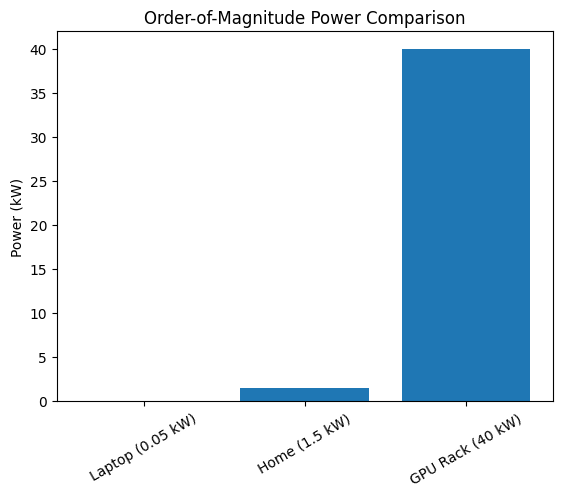

In [1]:
import matplotlib.pyplot as plt

devices = ["Laptop (0.05 kW)", "Home (1.5 kW)", "GPU Rack (40 kW)"]
power_values = [0.05, 1.5, 40]

plt.figure()
plt.bar(devices, power_values)
plt.ylabel("Power (kW)")
plt.title("Order-of-Magnitude Power Comparison")
plt.xticks(rotation=30)
plt.show()

# Notice the logarithmic difference. The GPU rack is not just “bigger” it’s 3 orders of magnitude larger than a laptop.
# And 40 kW is at the lower end of the required power range.

### Energy (Wh, kWh, MWh)

**Energy is power multiplied by time.**

It answers:

> How much total electricity was consumed?

This is like **distance**.

If you drive at 60 km/h for 2 hours:
- Distance = 120 km.

If a GPU rack draws 50 kW for 2 hours:
- Energy = 50 kW × 2 hours = 100 kWh.

Your electricity bill mostly reflects total energy consumed (kWh) over the billing period, not how intense your usage was at any one moment.

#### Unit conversions
- **1,000 Wh = 1 kWh**  
- **1,000 kWh = 1 MWh**  
- **1,000 MWh = 1 GWh**  
- **1,000 GWh = 1 TWh**  

#### Examples
- Laptop at 0.05 kW for **8 hours** → 0.4 kWh/day  
- Laptop at 0.05 kW for **24 hours** → 1.2 kWh/day

Notice how the time span changes the result.

#### Question 1

Complete the table below to see how much energy is consumed by these different users over a day or a month, assuming continuous use. The power values were picked as representative average value for that user.

| Device    | Power (kW) | Energy in 24h |  Energy in a month (30 days) |  
|-----------|-----|-------------|-------------|
| Laptop    | 0.05  |    |    |
| House     | 1.5   |    |    |
| CPU rack  | 10    |    |    |
| GPU rack  | 100   |    |    |

### Emissions (gCO₂e, kgCO₂e)

**CO₂e (carbon dioxide equivalent)** is a standard unit used to measure the total climate impact of all greenhouse gases (GHGs) combined, converting non-gases into the equivalent amount of CO₂ based on their global warming potential. It simplifies emissions reporting by aggregating gases like methane and nitrous oxide into one metric. It is typically reported with its mass unit (g, kg).

Producing electricity produces CO₂e, but the climate impact caused by consuming electricity changes depending on how it was produced.

1 kWh generated from hydro in Québec
≠
1 kWh generated from coal in a fossil-heavy grid

Emissions depend on many factors, including:

- Geographic location
- Time of day
- Grid mix (coal, gas, nuclear, hydro, wind, solar)
- Marginal generator on the grid*

When demand increases, the electricity that “ramps up” to meet that extra demand is often not the *average* resource - it’s the **marginal generator** (the one that adjusts output).

Example:
- If hydro is already maxed out, and you add demand at 6pm, the *extra* electricity might come from natural gas peakers.  
- That means your “extra kWh” can be dirtier than the daily average suggests.

Two identical ML training runs can have radically different carbon footprints depending on where and when they run.

#### Example 1: Québec

According to the [Canada Energy Regulator profile for Québec](https://www.cer-rec.gc.ca/en/data-analysis/energy-markets/provincial-territorial-energy-profiles/provincial-territorial-energy-profiles-quebec.html), Québec’s electricity generation intensity is about 1.2 gCO₂e/kWh (2022 estimate).

It is low because Québec electricity is dominated by hydroelectric generation. Hydro produces electricity with extremely low operational emissions.

#### Example 2: U.S.

The U.S. grid is highly heterogeneous. Coal-heavy regions have much higher emissions per kWh than hydro- or nuclear-heavy regions. Skim the [EPA eGRID summary tables](https://www.epa.gov/system/files/documents/2024-01/egrid2022_summary_tables.pdf) to see the state-level emission rates.


#### Question 2

In 1-2 sentences, explain why saying “my model used X kWh” not enough to answer the question “how much CO₂ did it cause?”

*Your answer here*

#### Question 3

The cell below is set up to make some basic energy consumption calculations and show the emissions produced by the same ML job executed on different grids.

In [2]:
# Power/Energy calculator utilities
def energy_kwh(power_kw: float, hours: float) -> float:
    """Energy (kWh) = Power (kW) × time (hours)."""
    return power_kw * hours

def emissions_kgco2e(energy_kwh: float, grid_intensity_g_per_kwh: float) -> float:
    """Emissions (kgCO2e) = energy (kWh) × grid intensity (g/kWh) ÷ 1000."""
    return energy_kwh * grid_intensity_g_per_kwh / 1000.0

# Scenario: same ML job, different grids
job_power_kw = 1.2   # e.g., a beefy workstation or a small GPU server averaged over the run
job_hours = 8        # one workday training run

job_kwh = energy_kwh(job_power_kw, job_hours)
print(f"Job energy: {job_kwh:.2f} kWh")

# Approximate grid intensities (gCO2e/kWh):
# Quebec (very low) — CER reports ~1.2 gCO2e/kWh for 2022 electricity generation intensity.
quebec_g = 1.2

# We'll use a placeholder *example* value here to illustrate order-of-magnitude.
virginia_example_g = 267.6  # <-- you can replace this value with your chosen eGRID value - just change the state name accordingly.

print("Emissions estimates:")
print(f"  Quebec:   {emissions_kgco2e(job_kwh, quebec_g):.4f} kgCO2e")
print(f"  Virginia: {emissions_kgco2e(job_kwh, virginia_example_g):.4f} kgCO2e")

Job energy: 9.60 kWh
Emissions estimates:
  Quebec:   0.0115 kgCO2e
  Virginia: 2.5690 kgCO2e


Complete the following tasks:
1. In the EPA eGRID summary tables, look up the CO₂e emissions for the state of Texas, and replace this value in the cell above (watch out for the unit conversion!)
2. Compute how many times the Texas' emissions are larger than Québec, as a ratio.
3. Compare the State Resource Mix of Virginia and Texas; what seems to be the reason why Virginia has lower emissions than Texas?

*Your answer here*

## Question 4 - Exercise: Estimating the Energy and Emissions of a New AI Application

A startup launches a real-time AI translation tool that runs on a dedicated GPU server.

The server draws **3 kW on average during operation**, and runs 18 hours per day, 30 days per month.

### Part A - Energy Use

1. What is the total monthly energy consumption (in kWh)?
2. How many average Canadian homes’ *daily* electricity use does this equal?

*(Assume an average home uses 30 kWh/day.)*


### Part B - Emissions Comparison

Now estimate emissions if this server runs in two different locations:

- Québec grid: 1.2 gCO₂e/kWh  
- Fossil-heavy grid: 450 gCO₂e/kWh  

3. What are the total monthly emissions (kgCO₂e) in each location?
4. How many times larger are emissions in the fossil-heavy grid?


### Part C - Infrastructure Thinking

5. If 1,000 companies deploy similar servers simultaneously, what is the total instantaneous power demand (in MW)?
6. At that scale, does this remain an IT issue (localized), or does it become a grid-planning issue? Briefly explain.


### Reflection

7. Which matters more for climate impact: the hardware choice, the runtime, or the grid location? Explain your reasoning.


## Physical scaling limits

Modern AI applications require increasingly high computational power as model sizes, dataset volumes, and algorithmic complexity continue to grow. Training state-of-the-art AI models can require tuning hundreds of billions of parameters, increasing the demand for high-performance GPUs and large-scale distributed computing infrastructure. The desire for larger models is driven by empirical evidence that model performance often improves with scale, including better accuracy, generalization, and the emergence of new capabilities such as reasoning and language understanding. Unfortunately, this idea clashes with the **physical limitations** of the infrastructure supporting these systems.

When someone says:

> “We’ll just add more GPUs.”

They are thinking in software terms. Infrastructure does not scale that way.
Scaling AI requires solving physical constraints.
- **Power feed upper bounds:** You can’t exceed what transmission/substations can deliver. If a site is connected to a substation rated for 80 MW - it cannot draw 120 MW without upgrades. Upgrades require: Engineering studies, Environmental review, Regulatory approval, Construction timelines (often years). Thus, electricity cannot be provisioned instantly.
- **Cooling constraints:** Heat removal becomes a first-class design problem. Failure to remove heat leads to: Hardware Damage and shutdowns.
- **Grid upgrades:** Permitting and construction takes years. There is a mismatch between digital growth and physical build timelines.
- **Water:** many cooling systems depend on water availability and local policy.
- **Economics & politics:** land use, community opposition, pricing structures.


## The black boxes of AI infrastructure

Cloud providers rarely disclose the full energy cost of AI inference. And even when they do, the methodology matters.

When someone posts:

> “A single AI prompt uses X Wh”

You should immediately ask:

- On what hardware?
- In what region?
- Under what workload?
- Including cooling?
- Using average or marginal emissions?

Measurement in AI infrastructure is not straightforward.

- MIT Technology Review (suggested reading): https://www.technologyreview.com/2025/05/20/1116327/ai-energy-usage-climate-footprint-big-tech/

A novice ML practicioner (you!) can measure easily:
- runtime on their machine,
- CPU/GPU utilization,
- energy proxy estimates (tools like CodeCarbon, which we'll see later).

But the following are often hidden:
- hardware type (exact GPU/TPU SKU, memory configuration),
- network + storage costs (caching layers, encryption),
- redundancy/replication,
- cooling and power conversion losses,
- where the job runs (grid mix).

### Question 5 - Google's transparency attempt
Google Cloud published a methodology estimating energy, emissions, and water for Gemini prompts:
- https://cloud.google.com/blog/products/infrastructure/measuring-the-environmental-impact-of-ai-inference

This is one of the first major cloud providers to publish prompt-level environmental metrics.

Reflect on this content and write a short critique of the information provided (100-200 words). In particular, reflect on the statement "One Gemini text query is equal to 9 seconds of watching TV": what are the limitations of this statement?  What would *you* want disclosed to make a more trustworthy estimate? 


*Your answer here*

## Accuracy/energy tradeoff

Jesse Dodge, a research scientist at the Allen Institute for AI, said: “When AI developers create new systems, they’re trying to push performance, accuracy, or the model’s capabilities, and they focus less on efficiency”. And it turns out that this focus on accuracy above everything else is costly. Here is a quote from a [2022 paper by Mill et al.](https://dl.acm.org/doi/pdf/10.1145/3514094.3534175):

There is a recognised trade-off between model accuracy and energy efficiency. In fact, the relationship has been shown to be logarithmic. That is, in order to achieve a linear improvement in accuracy, an exponentially larger model is required.

In this portion of the assignment, we will increase our awareness of the carbon footprint of our algorithms, thanks to a software tool called [CodeCarbon](https://codecarbon.io/). At the notebook level CodeCarbon can give us an approximate estimate of emissions associated with a task by combining runtime observations with inferred hardware power use and carbon-intensity assumptions. 

However, several critical components of energy consumption remain hidden. We cannot directly attribute energy usage to a single model in shared environments (multi-tenancy), nor can we fully capture the overhead of networking, storage, cooling, or replication within data centers. Additionally, emissions estimates depend on assumptions about grid carbon intensity, which may not reflect real-time or marginal energy sources.

Given these constraints, our methodology is structured around two principles:
- Measure what is observable (accuracy, latency, CodeCarbon emissions)
- Model what is not observable (compute proxies, scaling assumptions, and sensitivity analysis)
This approach allows us to reason rigorously about energy use while avoiding false precision. 

Let's start by installing the required packages in your environment.

In [6]:
%pip install -q codecarbon
import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib scikit-learn codecarbon

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# emissions tracking
try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
except Exception:
    CODECARBON_AVAILABLE = False
    EmissionsTracker = None

CODECARBON_AVAILABLE


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


True

We use the breast_cancer dataset as a controlled experimental environment. The purpose is not to maximize predictive performance, but to ensure that comparisons between models are internally valid.
Because this dataset is small and well-structured:
- runtime differences are primarily driven by model complexity, not data scale
- results are reproducible
- variance across runs is minimized
This allows us to isolate the relationship between model design and computational cost.

In [7]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

Traditional machine learning workflows optimize for accuracy alone. In contrast, we adopt a multi-objective evaluation framework, where each model is evaluated along four dimensions:
Performance → repeated cross-validation accuracy
Latency → fit and prediction time
Environmental cost → emissions (gCO₂e) via CodeCarbon
Compute complexity → proxy measures based on model structure

This reflects a broader shift in responsible AI:
A model is not “better” simply because it is more accurate,it must also be efficient and justifiable in its resource use.

In [12]:
# Repeated CV configuration
K = 5
REPEATS = 3

def repeated_cv_scores(model, X, y, K=5, repeats=3, scoring="accuracy", seed=0):
    scores = []
    for r in range(repeats):
        cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=seed + r)
        s = cross_val_score(model, X, y, cv=cv, scoring=scoring)
        scores.extend(s.tolist())
    return np.array(scores)

def summarize(arr):
    return {
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr, ddof=1)),
        "n": int(len(arr))
    }

### Model Suite: Designing for Trade-off Analysis
The purpose of including multiple models is to create a meaningful design space. Each model represents a different trade-off between:
- simplicity vs expressiveness
- speed vs accuracy
- computational cost vs performance
This enables Pareto analysis, where we identify models that are efficient rather than merely accurate.

In [13]:
models = {
    "Linear (LogReg)": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, solver="lbfgs")
    ),
    "Random Forest (200)": RandomForestClassifier(
        n_estimators=200, random_state=0, n_jobs=-1
    ),
    "Random Forest (600)": RandomForestClassifier(
        n_estimators=600, random_state=0, n_jobs=-1
    ),
    "GradBoost (100)": GradientBoostingClassifier(
        n_estimators=100, random_state=0
    ),
    "Small NN (MLP 64)": make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64,), max_iter=600, random_state=0)
    ),
    "Small NN (MLP 128)": make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(128,), max_iter=600, random_state=0)
    ),
}

list(models.keys())

['Linear (LogReg)',
 'Random Forest (200)',
 'Random Forest (600)',
 'GradBoost (100)',
 'Small NN (MLP 64)',
 'Small NN (MLP 128)']

### Measurement Utilities: Time as a Proxy for Energy

In [14]:
def measure_energy_and_emissions(func, *args, **kwargs):
    """
    Runs func and measures energy + emissions using CodeCarbon.

    Returns:
        (result, energy_kwh, emissions_kg, duration_s)
    """

    t0 = time.perf_counter()

    # If CodeCarbon not installed
    if not CODECARBON_AVAILABLE:
        out = func(*args, **kwargs)
        duration = time.perf_counter() - t0
        return out, np.nan, np.nan, duration

    tracker = EmissionsTracker(
        log_level="error",
        save_to_file=False,
        measure_power_secs=1
    )

    energy_kwh = np.nan
    emissions_kg = np.nan

    try:
        tracker.start()
        out = func(*args, **kwargs)

    finally:
        emissions_kg = tracker.stop()

        fed = getattr(tracker, "final_emissions_data", None)
        if fed is not None and hasattr(fed, "energy_consumed"):
            energy_kwh = float(fed.energy_consumed)

    duration = time.perf_counter() - t0

    if emissions_kg is None:
        emissions_kg = np.nan

    return out, energy_kwh, emissions_kg, duration

This function encapsulates a key idea:
Runtime is a first-order proxy for energy, while CodeCarbon provides a second-order estimate grounded in environmental assumptions.
By combining both, we obtain a more reliable estimate of computational cost.

In [15]:
# Accuracy with repeated CV
acc_summary = {}
for name, model in models.items():
    arr = repeated_cv_scores(model, X, y, K=K, repeats=REPEATS, seed=0)
    acc_summary[name] = summarize(arr)

acc_summary

{'Linear (LogReg)': {'mean': 0.9789266677017026,
  'std': 0.013975568805093909,
  'n': 15},
 'Random Forest (200)': {'mean': 0.9607773120115923,
  'std': 0.020388689068078683,
  'n': 15},
 'Random Forest (600)': {'mean': 0.9601769911504424,
  'std': 0.017500133444117643,
  'n': 15},
 'GradBoost (100)': {'mean': 0.9566319929617555,
  'std': 0.01808817368164872,
  'n': 15},
 'Small NN (MLP 64)': {'mean': 0.9730631889458159,
  'std': 0.013022560661331523,
  'n': 15},
 'Small NN (MLP 128)': {'mean': 0.9742327795890908,
  'std': 0.01216094193628462,
  'n': 15}}

In [16]:
def timed_fit_predict(model, X, y, n_pred_repeats=5):
    t0 = time.perf_counter()
    model.fit(X, y)
    fit_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    for _ in range(n_pred_repeats):
        _ = model.predict(X)
    pred_s = (time.perf_counter() - t1) / n_pred_repeats

    return fit_s, pred_s

# For neural networks, compute cost is closely related to the number of parameters. 
# This function calculates: parameters = ∑(weights + biases)
# This acts as a proxy for computational effort, since:
# more parameters → more matrix multiplications
# more memory + compute required

def mlp_param_count(hidden_sizes, n_in, n_out=1):
    sizes = [n_in] + list(hidden_sizes) + [n_out]
    total = 0
    for a, b in zip(sizes[:-1], sizes[1:]):
        total += a * b + b  # weights + bias
    return total

# deeper trees → more node evaluations per prediction
# more trees → more repeated computation
def compute_proxy(name, model, n_features):
    """
    Returns a relative compute proxy.
    - Linear: features
    - MLP: parameter count
    - Trees/boosting: computed later using depth * estimators, so return np.nan here
    """
    if "Linear" in name:
        return float(n_features)

    if "MLP 64" in name:
        return float(mlp_param_count((64,), n_features))

    if "MLP 128" in name:
        return float(mlp_param_count((128,), n_features))

    # Tree models: will be filled in after we estimate depth
    if ("Random Forest" in name) or ("GradBoost" in name):
        return np.nan

    return np.nan


from sklearn.base import clone
import re

# Each model is evaluated multiple times to account for variability in 
# CPU scheduling, background processes, thermal throttling
# This ensures that our measurements reflect consistent trends, not random noise.

TIME_REPEATS = 3
rows = []
n_features = X.shape[1]

def mean_tree_depth(tree):
    cl = tree.children_left
    cr = tree.children_right
    stack = [(0, 1)]
    max_depth = 0
    while stack:
        node, d = stack.pop()
        max_depth = max(max_depth, d)
        is_leaf = (cl[node] == cr[node])
        if not is_leaf:
            stack.append((cl[node], d + 1))
            stack.append((cr[node], d + 1))
    return max_depth


for name, model in models.items():
    fit_times, pred_times, emissions_g, energy_kwh = [], [], [], []
    depth_proxy = np.nan

    # repeated timing + emissions/energy
    for _ in range(TIME_REPEATS):
        m_clone = clone(model)

        # IMPORTANT: measure_energy_and_emissions expects a zero-arg function
        (fit_s, pred_s), E_kwh, e_kg, _ = measure_energy_and_emissions(
            lambda: timed_fit_predict(m_clone, X, y)
        )

        fit_times.append(fit_s)
        pred_times.append(pred_s)
        energy_kwh.append(E_kwh)
        emissions_g.append(e_kg * 1000 if not np.isnan(e_kg) else np.nan)

    # depth proxy computation (fit once)
    try:
        m2 = clone(model)
        m2.fit(X, y)

        if isinstance(m2, RandomForestClassifier):
            depths = [mean_tree_depth(est.tree_) for est in m2.estimators_]
            depth_proxy = float(np.mean(depths))

        elif isinstance(m2, GradientBoostingClassifier):
            depths = []
            for stage in m2.estimators_:
                for est in stage:
                    depths.append(mean_tree_depth(est.tree_))
            depth_proxy = float(np.mean(depths)) if depths else np.nan

        elif hasattr(m2, "named_steps"):
            last = list(m2.named_steps.values())[-1]
            if isinstance(last, RandomForestClassifier):
                depths = [mean_tree_depth(est.tree_) for est in last.estimators_]
                depth_proxy = float(np.mean(depths))
            elif isinstance(last, GradientBoostingClassifier):
                depths = []
                for stage in last.estimators_:
                    for est in stage:
                        depths.append(mean_tree_depth(est.tree_))
                depth_proxy = float(np.mean(depths)) if depths else np.nan
    except Exception:
        pass

    # compute proxy
    proxy = compute_proxy(name, model, n_features)

    if np.isnan(proxy):
        if "Random Forest" in name and not np.isnan(depth_proxy):
            match = re.search(r"\((\d+)\)", name)
            n_trees = int(match.group(1)) if match else 200
            proxy = float(n_trees * depth_proxy)

        elif "GradBoost" in name and not np.isnan(depth_proxy):
            match = re.search(r"\((\d+)\)", name)
            n_estimators = int(match.group(1)) if match else 100
            proxy = float(n_estimators * depth_proxy)

    rows.append({
        "model": name,
        "cv_acc_mean": acc_summary[name]["mean"], #average accuracy
        "cv_acc_std": acc_summary[name]["std"], #variability
        "fit_time_mean_s": float(np.mean(fit_times)),
        "fit_time_std_s": float(np.std(fit_times, ddof=1)) if len(fit_times) > 1 else 0.0,
        "pred_time_mean_s": float(np.mean(pred_times)),
        "pred_time_std_s": float(np.std(pred_times, ddof=1)) if len(pred_times) > 1 else 0.0,
        "total_time_mean_s": float(np.mean(np.array(fit_times) + np.array(pred_times))),
        "emissions_mean_gCO2e": float(np.nanmean(emissions_g)) if CODECARBON_AVAILABLE else np.nan,
        "energy_mean_kWh": float(np.nanmean(energy_kwh)) if CODECARBON_AVAILABLE else np.nan,
        "mean_tree_depth": depth_proxy,
        "compute_proxy_units": proxy
    })

results_df = pd.DataFrame(rows).sort_values("cv_acc_mean", ascending=False)
results_df

[codecarbon WARNING @ 19:43:47] Multiple instances of codecarbon are allowed to run at the same time.


,model,cv_acc_mean,cv_acc_std,fit_time_mean_s,fit_time_std_s,pred_time_mean_s,pred_time_std_s,total_time_mean_s,emissions_mean_gCO2e,energy_mean_kWh,mean_tree_depth,compute_proxy_units
0,Linear (LogReg),0.978927,0.013976,0.004755,0.000368,0.000214,0.000058,0.004968,0.000002,7.993172e-08,NaN,30.0
5,Small NN (MLP 128),0.974233,0.012161,0.196980,0.001309,0.000243,0.000018,0.197223,0.000054,2.508852e-06,NaN,4097.0
4,Small NN (MLP 64),0.973063,0.013023,0.161066,0.005257,0.000288,0.000118,0.161355,0.000045,2.058126e-06,NaN,2049.0
1,Random Forest (200),0.960777,0.020389,0.160266,0.002952,0.026501,0.000131,0.186767,0.000080,3.705981e-06,8.615000,1723.0
2,Random Forest (600),0.960177,0.017500,0.437574,0.016208,0.055018,0.007452,0.492592,0.000195,9.011464e-06,8.631667,5179.0
3,GradBoost (100),0.956632,0.018088,0.281182,0.001276,0.000616,0.000026,0.281798,0.000078,3.597054e-06,4.000000,400.0



For linear models, `compute_proxy_units` is roughly proportional to the number of features per example (a proxy for `O(d)` work per prediction). For MLPs, it uses parameter count (weights + biases), which roughly tracks compute and memory traffic during forward passes. For tree models, it uses `#estimators × mean_depth` as a proxy for node evaluations per prediction. They’re “proxies” because they are not actual FLOPs and they ignore vectorization, cache/memory effects, parallelism, batching, and hardware-specific execution details, but they still provide scaling intuition.

### Pareto Frontier (Dominance)

Pareto optimality reframes model selection as a multi-objective optimization problem. A model is only desirable if no other model achieves better accuracy at lower cost.

In [17]:
def pareto_nondominated(df, acc_col, cost_col):
    rows = df.to_dict("records")
    nd = []
    for i, a in enumerate(rows):
        dom = False
        for j, b in enumerate(rows):
            if i == j:
                continue
            if (b[acc_col] >= a[acc_col]) and (b[cost_col] <= a[cost_col]) and (
                (b[acc_col] > a[acc_col]) or (b[cost_col] < a[cost_col])
            ):
                dom = True
                break
        if not dom:
            nd.append(a["model"])
    return nd

nd_time = pareto_nondominated(results_df, "cv_acc_mean", "total_time_mean_s")
nd_time


['Linear (LogReg)']

Pareto frontier under “accuracy up, runtime down” returned `['Linear (LogReg)']`. This means every other model is *dominated* by Logistic Regression: they are slower and do not achieve higher mean CV accuracy. This can happen because the breast_cancer dataset is relatively small and close to linearly separable after scaling, so linear models already perform near a ceiling. Additional model complexity can add variance/overfitting and compute cost without improving accuracy.

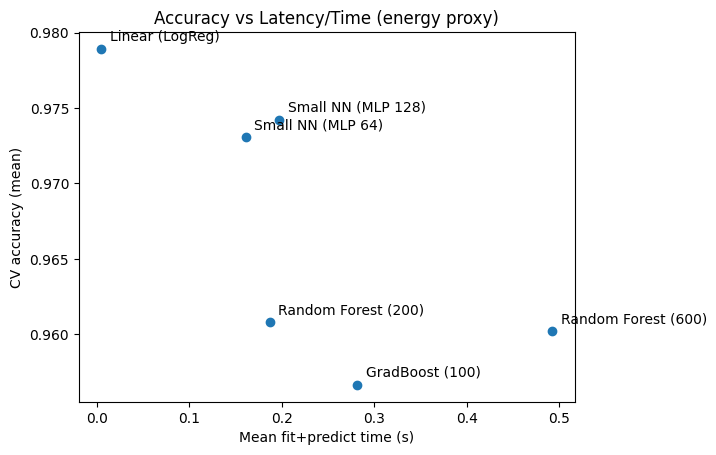

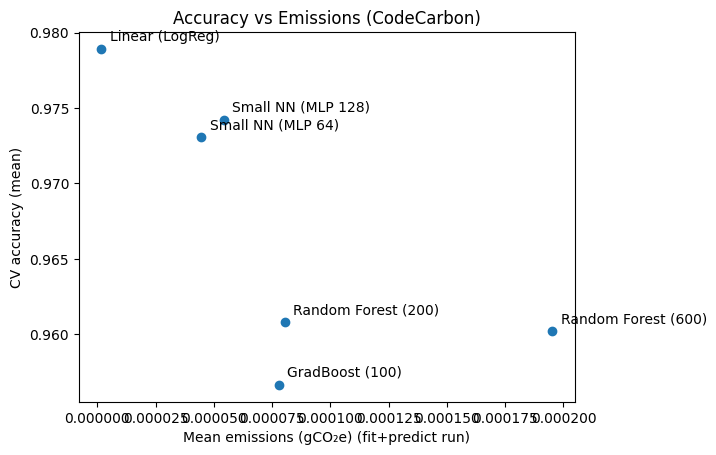

In [18]:
# Visualize accuracy vs time
plt.figure()
plt.scatter(results_df["total_time_mean_s"], results_df["cv_acc_mean"])
for _, r in results_df.iterrows():
    plt.annotate(r["model"], (r["total_time_mean_s"], r["cv_acc_mean"]), textcoords="offset points", xytext=(6,6))
plt.xlabel("Mean fit+predict time (s)")
plt.ylabel("CV accuracy (mean)")
plt.title("Accuracy vs Latency/Time (energy proxy)")
plt.show()

if CODECARBON_AVAILABLE:
    plt.figure()
    plt.scatter(results_df["emissions_mean_gCO2e"], results_df["cv_acc_mean"])
    for _, r in results_df.iterrows():
        plt.annotate(r["model"], (r["emissions_mean_gCO2e"], r["cv_acc_mean"]), textcoords="offset points", xytext=(6,6))
    plt.xlabel("Mean emissions (gCO₂e) (fit+predict run)")
    plt.ylabel("CV accuracy (mean)")
    plt.title("Accuracy vs Emissions (CodeCarbon)")
    plt.show()


In [19]:
#choose best accuracy under a time threshold.
def best_under_time(df, thr_s):
    feasible = df[df["total_time_mean_s"] <= thr_s].copy()
    if feasible.empty:
        return None, feasible
    best = feasible.sort_values("cv_acc_mean", ascending=False).iloc[0]
    return best, feasible

for thr in [0.2, 0.5, 1.0, 2.0]:
    best, feasible = best_under_time(results_df, thr)
    print(f"thr={thr:.2f}s | feasible={len(feasible)}", end="")
    if best is None:
        print(" | best=None")
    else:
        print(f" | best={best['model']} | acc={best['cv_acc_mean']:.4f} | time={best['total_time_mean_s']:.4f}s")


thr=0.20s | feasible=4 | best=Linear (LogReg) | acc=0.9789 | time=0.0050s
thr=0.50s | feasible=6 | best=Linear (LogReg) | acc=0.9789 | time=0.0050s
thr=1.00s | feasible=6 | best=Linear (LogReg) | acc=0.9789 | time=0.0050s
thr=2.00s | feasible=6 | best=Linear (LogReg) | acc=0.9789 | time=0.0050s


### Rebound Effect: Efficiency Does Not Guarantee Sustainability
Even if models become more efficient, total energy consumption may increase due to increased usage. This is an instance of Jevons Paradox, where efficiency gains lower cost and thereby increase demand.

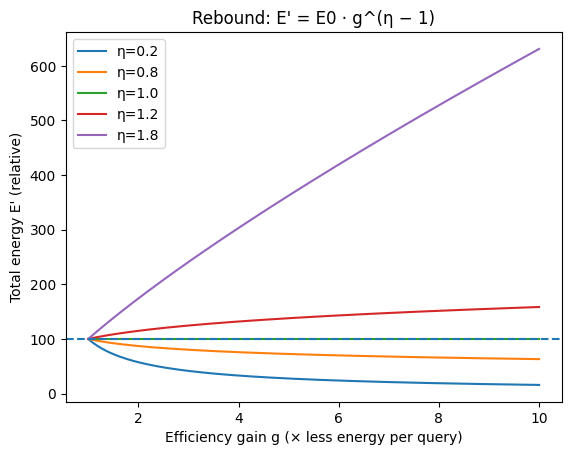

In [20]:
def E_after(E0, g, eta):
    return E0 * (g ** (eta - 1.0))

E0 = 100.0
gains = np.linspace(1, 10, 200)
etas = [0.2, 0.8, 1.0, 1.2, 1.8]

plt.figure()
for eta in etas:
    plt.plot(gains, [E_after(E0, g, eta) for g in gains], label=f"η={eta}")
plt.axhline(E0, linestyle="--")
plt.xlabel("Efficiency gain g (× less energy per query)")
plt.ylabel("Total energy E' (relative)")
plt.title("Rebound: E' = E0 · g^(η − 1)")
plt.legend()
plt.show()


#### Question 6: If efficiency improves by 5× (energy/query becomes 1/5) and demand increases by 8×, what is the total energy multiplier? Interpret in one sentence.

**Answer:**  
Total energy multiplier is (1/5) × 8 = 1.6×. Total energy increases by 60% despite efficiency gains, which is a rebound effect.

In [21]:
from sklearn.base import clone

def fit_predict_once(model):
    m = clone(model)
    return timed_fit_predict(m, X, y)

energy_rows = []
for name in ["Linear (LogReg)", "Random Forest (200)"]:
    model = models[name]
    (_, _), E_kwh, e_kg, dur = measure_energy_and_emissions(lambda: fit_predict_once(model))
    energy_rows.append({"model": name, "energy_kwh": E_kwh, "codecarbon_emissions_g": e_kg*1000, "duration_s": dur})

energy_df = pd.DataFrame(energy_rows)
energy_df

,model,energy_kwh,codecarbon_emissions_g,duration_s
0,Linear (LogReg),8.237301e-08,0.000002,3.163498
1,Random Forest (200),3.636225e-06,0.000079,3.424834


### Question 7: Put each intervention into one bucket and justify in one sentence:

- early stopping  
- carbon-aware scheduling  
- rate limits/pricing  
- reduce hyperparameter search  
- caching/batching  

Buckets:  
(A) reduces **energy per task**  
(B) reduces **total emissions** by reducing usage and/or shifting to lower carbon intensity

**Answer:**  
- Early stopping → **A** (reduces training compute for the same modeling pipeline).  
- Carbon-aware scheduling → **B** (shifts the same energy use to times/places with lower carbon intensity).  
- Rate limits/pricing → **B** (reduces demand/total number of queries).  
- Reduce hyperparameter search → **A** (fewer trials → fewer training runs).  
- Caching/batching → **A** (avoids redundant work and improves per-query efficiency).

### Impact on the Global South and energy-access-constrained regions

AI infrastructure is often discussed as if it exists in a vacuum:
bigger models, better chips, faster inference, more scale.

But electricity systems are political and unequal.

At the same time that AI data centre demand is accelerating, the world still has hundreds of millions of people without basic electricity access. The World Bank's *Tracking SDG 7: The Energy Progress Report 2025* reports that global electricity access reached about **92%** in 2023, yet **more than 666 million people** still lacked access to electricity. The report also notes that current progress is not fast enough to reach universal access by 2030. In related IEA commentary, sub-Saharan Africa accounts for roughly 80% of the global population without electricity access.  
- World Bank / Tracking SDG7 2025: https://www.worldbank.org/en/topic/energy/publication/tracking-sdg-7-the-energy-progress-report-2025
- IEA commentary on electricity access stagnation: https://www.iea.org/commentaries/access-to-electricity-stagnates-leaving-globally-730-million-in-the-dark

That means AI energy discussions are not only about **efficiency**.
They are also about **distribution** and **justice**.

Large AI systems can deepen inequality in at least three distinct ways:

**1. Infrastructure competition**
Regions with the most capital, bargaining power, and existing grid strength attract high-value compute.
Regions with weaker infrastructure remain consumers of AI services rather than owners of compute infrastructure.

**2. Value extraction**
Data, labor, and users may come from the Global South, while high-margin compute ownership, model hosting, and cloud rents remain concentrated elsewhere.

**3. Development trade-offs**
If national planning focuses on export-oriented or elite digital infrastructure without parallel investments in broad-based energy access, then AI expansion can widen rather than reduce inequality.

This does **not** mean AI is inherently harmful in lower-income countries.
It means the question is:
> **What kind of AI, built for whom, powered how, under whose control?**

## Question 8 - Case study: proposed AI data centre development in Alberta

Alberta is becoming a major site of data-centre and AI-infrastructure discussion because it offers:
- relatively fast project development pathways,
- abundant energy resources,
- a policy interest in attracting AI and data-centre investment,

Alberta's Major Projects portal describes **[Wonder Valley AI Data Centre Park (Phase 1)]( https://majorprojects.alberta.ca/details/Wonder-Valley-AI-Data-Centre-Park/11477)** in the Greenview Industrial Gateway as the initial phase of what is framed as a very large AI data centre industrial park. The listing describes Phase 1 as involving a **1.4-gigawatt off-grid power system**, leveraging **natural gas and geothermal resources**.  

For broader provincial context, [Alberta's 2026 budget materials](https://open.alberta.ca/dataset/3393a7b5-07bf-4b9f-8aaf-a6d89273297b/resource/ae68d9e0-8da0-4052-897c-c7e94c055206/download/budget-2026-ministry-business-plans-2026-29.pdf) state that the province is finalizing an **AI data centre attraction strategy** intended to enhance investment attractiveness with stable, affordable electricity and “fair” market participation.  

Using the sources linked above and others (found through independent inquiry), as well as the material covered in this module and other modules of the course, answer the following questions:
1. What are the strongest arguments **for** this project from the perspective of:
    - regional development,
    - jobs,
    - industrial strategy,
    - technological sovereignty,
    - attracting investment
2. What are the strongest arguments **against** this project from the perspective of:
    - emissions,
    - fossil lock-in,
    - land use,
    - local grid effects,
    - environmental justice,
    - opportunity cost
3. If the operator claims the project is “sustainable,” what **specific evidence** would you ask for? Try to name at least 3 distinct items.

If using additional sources, please link them at the end of your answers.

*Your answer here*

### Additional Resources

To better understand the broader implications of large-scale AI systems, especially their impact on energy infrastructure and society, you may watch the following video:

- **Should We Feel Guilty Using AI?**  
  https://youtu.be/5sFBySzNIX0?si=6Zkbl7_EmJ2hGq17

# Final thoughts

1) If you have completed this assignment in a group, please write a detailed description of how you divided the work and how you helped each other completing it:

2) Have you used ChatGPT or a similar Large Language Model (LLM) to complete this homework? Please describe how you used the tool. We will never deduct points for using LLMs for completing homework assignments, but this helps us understand how you are using the tool and advise you in case we believe you are using it incorrectly.

3) Have you struggled with some parts (or all) of this homework? Do you have pending questions you would like to ask? Write them down here!